# 30. Модель после запуска: сдвиг данных, мониторинг и переобучение за 12 месяцев

| | |
|---|---|
| **Уровень** | 4 из 4 — большие данные и сложные задачи (`4_large`) |
| **Скрипт-источник** | [`30_drift_monitoring_retraining.py`](../30_drift_monitoring_retraining.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 7 с |

**Цель.** Понять, почему качество модели со временем падает, как это заметить и когда переобучать.

### Чему вы научитесь

- Сдвиг признаков (covariate shift) и сдвиг зависимости (concept drift)
- Индекс стабильности популяции (PSI)
- Состязательная проверка (adversarial validation)
- Мониторинг смещения прогноза, когда факт приходит с задержкой
- Стратегии переобучения

### Данные

`_data.make_houses` — 12 месяцев сделок по 3000 квартир; с каждым месяцем цены растут на 1.5% (инфляция — сдвиг зависимости), а доля новостроек и больших квартир — увеличивается (сдвиг признаков).

### План

1. **Этап 1.** Симуляция: 12 месяцев по 3000 сделок
2. **Этап 2.** Модель обучена на 2/3 месяца 0 и больше не меняется; оставшаяся 1/3 — честная проверка месяца 0
3. **Этап 3.** Мониторинг: PSI признаков (есть сразу), PSI прогноза и смещение (когда придёт факт)
4. **Этап 4.** Состязательная проверка: отличит ли классификатор месяц 0 от месяца 11?
5. **Этап 5.** Стратегии на месяцах 6–11: не трогать / переобучать ежемесячно на всём / на последних 3 месяцах
6. **Этап 6.** График: ошибка и смещение модели месяца 0
7. **Этап 7.** Выводы

> Ноутбук собран из `examples/4_large/30_drift_monitoring_retraining.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_houses

ex = Example(EXAMPLES / "4_large/30_drift_monitoring_retraining.py", title="30. Сдвиг данных, мониторинг и переобучение",
             goal="заметить деградацию модели и правильно переобучить")

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gbcourse.style import ROLE
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_predict

INFLATION = 0.015
MONTHS = 12

## Этап 1. Симуляция: 12 месяцев по 3000 сделок

In [2]:
per_month = ex.size(3000, 1000)
pool, pool_price = make_houses(per_month * MONTHS * 3, seed=30)
rng = np.random.default_rng(1)
months = []
for t in range(MONTHS):
    # сдвиг признаков: с каждым месяцем чаще отбираем новые дома и большие квартиры
    w = np.exp(0.15 * t * ((pool["год"] > 2010).to_numpy() + (pool["площадь"] > 70).to_numpy()))
    idx = rng.choice(len(pool), per_month, replace=False, p=w / w.sum())
    Xm = pool.iloc[idx].reset_index(drop=True)
    ym = pool_price[idx] * (1 + INFLATION) ** t                   # сдвиг зависимости: та же квартира дорожает
    months.append((Xm, ym))
for t in (0, 5, 11):
    Xm, ym = months[t]
    print(f"   месяц {t:2d}: новостроек {np.mean(Xm['год'] > 2010):.1%}, площадь > 70 м² {np.mean(Xm['площадь'] > 70):.1%}, "
          f"медианная цена {np.median(ym):.2f} млн")

params = dict(n_estimators=400, learning_rate=0.05, num_leaves=31, verbose=-1, random_state=0)
fit = lambda X_, y_: lgb.LGBMRegressor(**params).fit(X_, np.log(y_))
pred = lambda m, X_: np.exp(m.predict(X_))
mape = lambda y_, p: float(np.mean(np.abs(p - y_) / y_))


def psi(expected, actual, bins=10):
    """Индекс стабильности популяции: Σ (a − e)·ln(a / e) по корзинам квантилей эталона. < 0.1 — спокойно, > 0.25 — тревога."""
    cuts = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)[1:-1]))
    e = np.bincount(np.searchsorted(cuts, expected), minlength=len(cuts) + 1) / len(expected)
    a = np.bincount(np.searchsorted(cuts, actual), minlength=len(cuts) + 1) / len(actual)
    e, a = np.clip(e, 1e-4, None), np.clip(a, 1e-4, None)
    return float(np.sum((a - e) * np.log(a / e)))

   месяц  0: новостроек 14.6%, площадь > 70 м² 23.4%, медианная цена 7.99 млн
   месяц  5: новостроек 22.8%, площадь > 70 м² 36.2%, медианная цена 9.54 млн
   месяц 11: новостроек 32.5%, площадь > 70 м² 48.2%, медианная цена 11.58 млн


## Этап 2. Модель обучена на 2/3 месяца 0 и больше не меняется; оставшаяся 1/3 — честная проверка месяца 0

In [3]:
Xfull0, yfull0 = months[0]
cut0 = 2 * len(yfull0) // 3
X0, y0 = Xfull0.iloc[:cut0], yfull0[:cut0]
months[0] = (Xfull0.iloc[cut0:].reset_index(drop=True), yfull0[cut0:])      # в мониторинг идёт только отложенная часть
model0 = fit(X0, y0)
print(f"   обучение: {len(y0)} сделок месяца 0")

   обучение: 2000 сделок месяца 0

## Этап 3. Мониторинг: PSI признаков (есть сразу), PSI прогноза и смещение (когда придёт факт)

In [4]:
print("   месяц  PSI год  PSI площадь  PSI прогноза  ср. прогноз/факт  ошибка MAPE  сигнал")
log = []
for t, (Xm, ym) in enumerate(months):
    p = pred(model0, Xm)
    row = dict(t=t, psi_year=psi(X0["год"], Xm["год"]), psi_area=psi(X0["площадь"], Xm["площадь"]),
               psi_pred=psi(pred(model0, X0), p), bias=float(np.mean(p / ym)), mape=mape(ym, p))
    row["alarm"] = row["psi_pred"] > 0.1 or abs(row["bias"] - 1) > 0.05
    log.append(row)
    print(f"   {t:5d}  {row['psi_year']:7.3f}  {row['psi_area']:11.3f}  {row['psi_pred']:12.3f}  {row['bias']:16.3f}  "
          f"{row['mape']:11.1%}  {'ПЕРЕОБУЧИТЬ' if row['alarm'] else ''}")
first_alarm = next(r["t"] for r in log if r["alarm"])
first_psi = next((r["t"] for r in log if max(r["psi_year"], r["psi_area"]) > 0.1), None)
ex.note(f"""PSI признаков считается сразу, без факта цены, и плавно растёт; порог 0.1 он переходит в месяце {first_psi}.
Но инфляция — сдвиг зависимости — во входах не видна вовсе: её ловит только смещение прогноза относительно факта,
а оно выходит за 5% уже в месяце {first_alarm}. Поэтому нужны оба сигнала: по входам (рано) и по факту (надёжно).""")

   месяц  PSI год  PSI площадь  PSI прогноза  ср. прогноз/факт  ошибка MAPE  сигнал
       0    0.008        0.016         0.013             1.002         8.2%  
       1    0.010        0.010         0.013             0.990         8.6%  
       2    0.019        0.025         0.024             0.976         8.8%  
       3    0.025        0.038         0.014             0.962         9.1%  
       4    0.046        0.058         0.043             0.943         9.6%  ПЕРЕОБУЧИТЬ
       5    0.044        0.092         0.048             0.931        10.2%  ПЕРЕОБУЧИТЬ
       6    0.064        0.118         0.070             0.914        11.2%  ПЕРЕОБУЧИТЬ
       7    0.088        0.128         0.071             0.903        11.7%  ПЕРЕОБУЧИТЬ
       8    0.093        0.162         0.080             0.888        12.8%  ПЕРЕОБУЧИТЬ
       9    0.119        0.244         0.120             0.874        13.7%  ПЕРЕОБУЧИТЬ
      10    0.127        0.238         0.143             0.861        

> ▸ **Вывод.** PSI признаков считается сразу, без факта цены, и плавно растёт; порог 0.1 он переходит в месяце 6. Но инфляция — сдвиг зависимости — во входах не видна вовсе: её ловит только смещение прогноза относительно факта, а оно выходит за 5% уже в месяце 4. Поэтому нужны оба сигнала: по входам (рано) и по факту (надёжно).

## Этап 4. Состязательная проверка: отличит ли классификатор месяц 0 от месяца 11?

In [5]:
Xa = pd.concat([Xfull0, months[-1][0]], ignore_index=True)
ya = np.r_[np.zeros(len(Xfull0)), np.ones(len(months[-1][0]))]
pa = cross_val_predict(lgb.LGBMClassifier(n_estimators=200, verbose=-1, random_state=0), Xa, ya, cv=5, method="predict_proba")[:, 1]
imp = lgb.LGBMClassifier(n_estimators=200, verbose=-1, random_state=0).fit(Xa, ya).booster_.feature_importance("gain")
print(f"   AUC {roc_auc_score(ya, pa):.3f} (0.5 — неотличимы); сильнее всего отличают: "
      + ", ".join(c for c, _ in sorted(zip(Xa.columns, imp), key=lambda t: -t[1])[:3]))
ex.note("Состязательная проверка сразу показывает, что и в каких признаках изменилось. Цена при этом не нужна.")

   AUC 0.678 (0.5 — неотличимы); сильнее всего отличают: год, площадь, кухня


> ▸ **Вывод.** Состязательная проверка сразу показывает, что и в каких признаках изменилось. Цена при этом не нужна.

## Этап 5. Стратегии на месяцах 6–11: не трогать / переобучать ежемесячно на всём / на последних 3 месяцах

In [6]:
res = {"не трогать": [], "на всей истории": [], "скользящее окно 3 мес.": []}
for t in range(6, MONTHS):
    Xm, ym = months[t]
    hist = [(Xfull0, yfull0)] + months[1:t]                      # факт известен за все прошедшие месяцы
    res["не трогать"].append(mape(ym, pred(model0, Xm)))
    res["на всей истории"].append(mape(ym, pred(fit(pd.concat([h[0] for h in hist]), np.concatenate([h[1] for h in hist])), Xm)))
    res["скользящее окно 3 мес."].append(mape(ym, pred(fit(pd.concat([h[0] for h in hist[-3:]]),
                                                            np.concatenate([h[1] for h in hist[-3:]])), Xm)))
for name, v in res.items():
    print(f"   {name:24s} средняя MAPE {np.mean(v):.2%}   в месяце 11: {v[-1]:.2%}")
ex.note("""Вся история даёт больше данных, но старые цены тянут прогноз вниз. Короткое окно свежее, но меньше данных.
При инфляции помогает и третий путь — признак времени или прогноз в «сегодняшних» ценах (деление на индекс).""")

   не трогать               средняя MAPE 13.41%   в месяце 11: 15.99%
   на всей истории          средняя MAPE 8.38%   в месяце 11: 9.23%
   скользящее окно 3 мес.   средняя MAPE 7.13%   в месяце 11: 7.13%


> ▸ **Вывод.** Вся история даёт больше данных, но старые цены тянут прогноз вниз. Короткое окно свежее, но меньше данных. При инфляции помогает и третий путь — признак времени или прогноз в «сегодняшних» ценах (деление на индекс).

## Этап 6. График: ошибка и смещение модели месяца 0

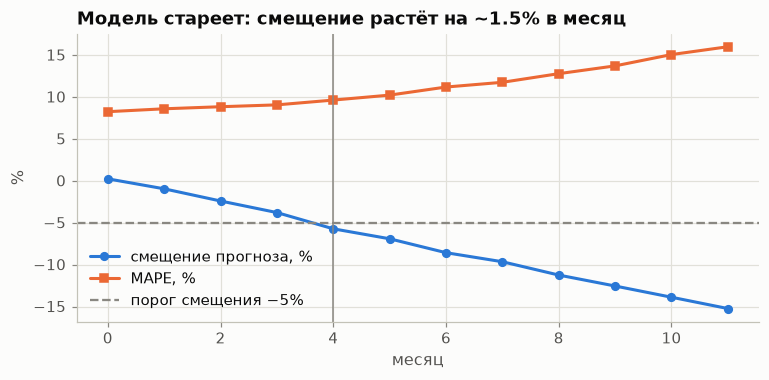

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot([r["t"] for r in log], [100 * (r["bias"] - 1) for r in log], "o-", color=ROLE["model"], lw=2, label="смещение прогноза, %")
ax.plot([r["t"] for r in log], [100 * r["mape"] for r in log], "s-", color=ROLE["tree"], lw=2, label="MAPE, %")
ax.axhline(-5, color=ROLE["truth"], ls="--", lw=1.5, label="порог смещения −5%")
ax.axvline(first_alarm, color=ROLE["residual"], lw=1)
ax.set(xlabel="месяц", ylabel="%", title="Модель стареет: смещение растёт на ~1.5% в месяц")
ax.legend()
ex.finish(fig, "30_drift")

## Этап 7. Выводы

In [8]:
ex.note("""Мониторьте три слоя: входы (PSI, состязательная проверка) — сразу; прогнозы (их распределение) — сразу;
качество (смещение, ошибка) — когда придёт факт. Правило переобучения задают заранее и проверяют на истории.""")
ex.done()

> ▸ **Вывод.** Мониторьте три слоя: входы (PSI, состязательная проверка) — сразу; прогнозы (их распределение) — сразу; качество (смещение, ошибка) — когда придёт факт. Правило переобучения задают заранее и проверяют на истории.

Готово за 5.1 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Переведите цены в «сегодняшние» (разделите на индекс инфляции) — нужно ли тогда ежемесячное переобучение?
2. Подберите размер окна (1, 3, 6 месяцев) по средней ошибке.
3. Добавьте признак «месяц сделки» и обучите модель на всей истории.

## Что дальше

- **Теория в курсе:** [13.3 «Эксплуатация»](../../../lessons/lesson_13_3/README.md).
- **Предыдущий пример:** [29. От данных до сервиса: конвейер, проверка, сохранение, функция прогноза и карточка модели](29_end_to_end_pipeline.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)